# Linear Regression — Practice Notebook

Fit a linear regression model with PyTorch on a synthetic dataset: generate the data, train with a manual training loop, and compare the learned parameters against the ground truth.

## Setup

In [13]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
import random

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
from sklearn.datasets import make_regression
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm

from dl_roadmap.data import train_test_split
from dl_roadmap.utils import seed_everything
from dl_roadmap.visualization import plot_training_history

In [15]:
%matplotlib inline

pd.set_option("display.width", 150)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", None)

In [16]:
seed_everything()

## Dataset

In [ ]:
# Generate dataset
real_bias = random.random() * 100  # noqa: S311
X_numpy, y_numpy, real_coef = make_regression(
    n_samples=250, n_features=1, noise=25, bias=real_bias, coef=True
)

# Convert to torch tensor
X, y = torch.from_numpy(X_numpy).float(), torch.from_numpy(y_numpy).float()
y = y.unsqueeze(1)

# Split to train / val
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)

# Train dataset
train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=25,
    shuffle=True,
    drop_last=False,  # keep the last smaller batch
)

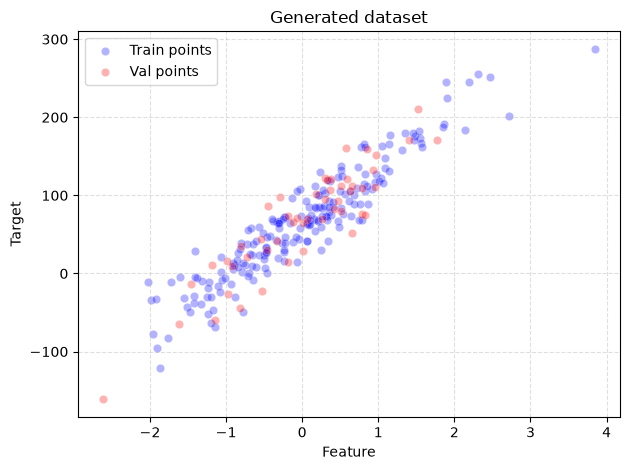

In [18]:
sns.scatterplot(
    x=X_train.flatten(),
    y=y_train.flatten(),
    alpha=0.3,
    label="Train points",
    c="b",
)
sns.scatterplot(
    x=X_val.flatten(),
    y=y_val.flatten(),
    alpha=0.3,
    label="Val points",
    c="r",
)
plt.title("Generated dataset")
plt.xlabel("Feature")
plt.ylabel("Target")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## Training

In [19]:
epochs = 3000
device = "cpu"

In [ ]:
pbar = tqdm(
    range(epochs),
    desc="Processing",
    ascii=" >=",
    ncols=100,
    bar_format="{desc}: [{bar:30}] {n_fmt}/{total_fmt}{postfix}",
)

model = nn.Linear(1, 1)

opt = torch.optim.Adam(model.parameters(), lr=1e-2, weight_decay=0.01)
loss_fn = nn.MSELoss()

history = {"train_loss": [], "val_loss": []}

for _ in pbar:
    model.train()

    for xb, yb in train_loader:
        xb_device = xb.to(device)
        yb_device = yb.to(device)

        logits = model(xb_device)
        train_loss = loss_fn(logits, yb_device)

        with torch.no_grad():
            val_logits = model(X_val)
            val_loss = loss_fn(val_logits, y_val)

            assert not val_loss.requires_grad  # noqa: S101

        opt.zero_grad()
        train_loss.backward()
        opt.step()

    history["train_loss"].append(train_loss.detach().item())
    history["val_loss"].append(val_loss.detach().item())

    pbar.set_postfix_str(f"train loss: {train_loss:.1f}, val loss: {val_loss:.1f}")

Processing: [==============================] 3000/3000, train loss: 473.6, val loss: 857.5  


## Results

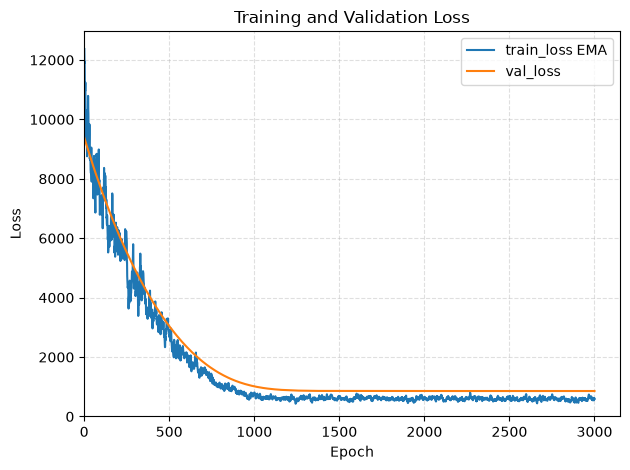

In [21]:
plot_training_history(**history)

In [22]:
pd.DataFrame(
    data={
        "coef": [real_coef, model.weight.detach().item()],
        "bias": [real_bias, model.bias.detach().item()],
    },
    index=["real", "pytorch"],
)

,coef,bias
real,66.01973767177313,63.942680
pytorch,66.835358,65.333427


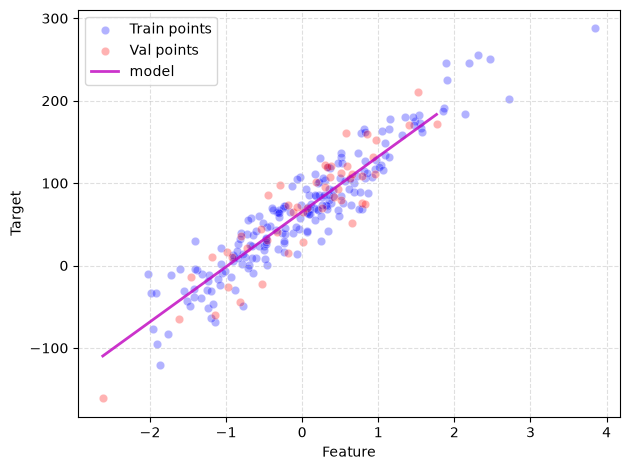

In [23]:
model_predictions = model(X_val).detach()

sns.scatterplot(
    x=X_train.flatten(),
    y=y_train.flatten(),
    alpha=0.3,
    label="Train points",
    c="b",
)
sns.scatterplot(
    x=X_val.flatten(),
    y=y_val.flatten(),
    alpha=0.3,
    label="Val points",
    c="r",
)
sns.lineplot(
    x=X_val.numpy().flatten(),
    y=model_predictions.numpy().flatten(),
    color="m",
    label="model",
    alpha=0.8,
    markersize=8,
    linewidth=2,
)

plt.xlabel("Feature")
plt.ylabel("Target")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()